# Counterfactual phenotype traversal violins (Figure 4)

Morphometric readout of the DiffAE counterfactual traversal for three example targets, one metric each:
**POLR1B** (nucleolar circularity), **TIM23 complex** (mitochondrial network degree), and **mTOR**
(lysosome radial position). Each panel shows real NTC, real KO, and the generated traversal at
α = 0, 1, 2, 3 (α=0 = DDIM-inverted reconstruction of the real NTC anchor; α=1 ≈ the KO mean; α>1
extrapolates beyond it).

**Normalization.** Every value is a %-change against a single shared baseline — the **real-NTC mean** for
that feature — applied identically to real NTC, real KO, and every generated α:

```
pct(x) = (x - mean(real_ntc)) / |mean(real_ntc)| * 100
```

Real NTC therefore sits at 0% by construction; real KO and each generated α show the measured effect size
on the same scale, so all three panels (different native units — circularity is unitless, degree is
unitless, radial position is a normalized 0–1 fraction) are directly comparable.

Inputs are the per-cell measured values (native units, pre-normalization), committed alongside this
notebook:

| file | target | feature |
| --- | --- | --- |
| `polr1b_circularity_traversal.csv` | POLR1B (nucleolus, phase) | circularity (4π·area/perimeter²) |
| `tim23_degree_traversal.csv` | TIM23 complex (mitochondria) | mean network degree |
| `mtor_location_traversal.csv` | mTOR (lysosome) | radial position (0 = nucleus, 1 = cell edge) |

Each CSV is long-format: `series` (`real_ntc`, `real_ko`, `gen_alpha0..3`) × `value` (one row per cell).


## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# Keep text editable in Illustrator (SVG keeps <text> elements rather than
# path-tracing the glyphs; PDF uses TrueType instead of Type-3).
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

FIGURES_DIR = Path("../../output/figure_4")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Data paths

In [2]:
FIGURE_DATA = Path(".")  # CSVs sit alongside this notebook

FEATURES = [
    dict(key="polr1b", csv="polr1b_circularity_traversal.csv",
         title="POLR1B \u2014 nucleolar circularity", ylabel="circularity"),
    dict(key="tim23", csv="tim23_degree_traversal.csv",
         title="TIM23 complex \u2014 mitochondrial network degree", ylabel="network degree"),
    dict(key="mtor", csv="mtor_location_traversal.csv",
         title="mTOR \u2014 lysosome radial position", ylabel="radial position"),
]

## Configuration

In [3]:
SERIES = ["real_ntc", "real_ko", "gen_alpha0", "gen_alpha1", "gen_alpha2", "gen_alpha3"]
LABELS = ["real\nNTC", "real\nKO", "\u03b1=0", "\u03b1=1", "\u03b1=2", "\u03b1=3"]

COLORS = {
    "real_ntc": "#999999", "real_ko": "#2e8b57",
    "gen_alpha0": "#c6dbef", "gen_alpha1": "#6baed6",
    "gen_alpha2": "#3182bd", "gen_alpha3": "#08519c",
}

## Load

In [4]:
def load(csv_name: str) -> dict[str, np.ndarray]:
    df = pd.read_csv(FIGURE_DATA / csv_name)
    return {s: df.loc[df["series"] == s, "value"].to_numpy() for s in SERIES}

data = {f["key"]: load(f["csv"]) for f in FEATURES}
for f in FEATURES:
    counts = {s: len(data[f["key"]][s]) for s in SERIES}
    print(f"{f['key']}: {counts}")

polr1b: {'real_ntc': 98, 'real_ko': 93, 'gen_alpha0': 96, 'gen_alpha1': 93, 'gen_alpha2': 97, 'gen_alpha3': 75}
tim23: {'real_ntc': 1000, 'real_ko': 500, 'gen_alpha0': 100, 'gen_alpha1': 100, 'gen_alpha2': 100, 'gen_alpha3': 100}
mtor: {'real_ntc': 1000, 'real_ko': 1000, 'gen_alpha0': 100, 'gen_alpha1': 100, 'gen_alpha2': 100, 'gen_alpha3': 100}


## Figure

One panel per target; violins follow the repo convention (`showmedians=True, showextrema=True`, black
median/whisker lines). Values are %-change vs. the real-NTC mean (see Normalization above), so real NTC
sits at 0% in every panel and the three panels — different native units — are on one comparable axis.

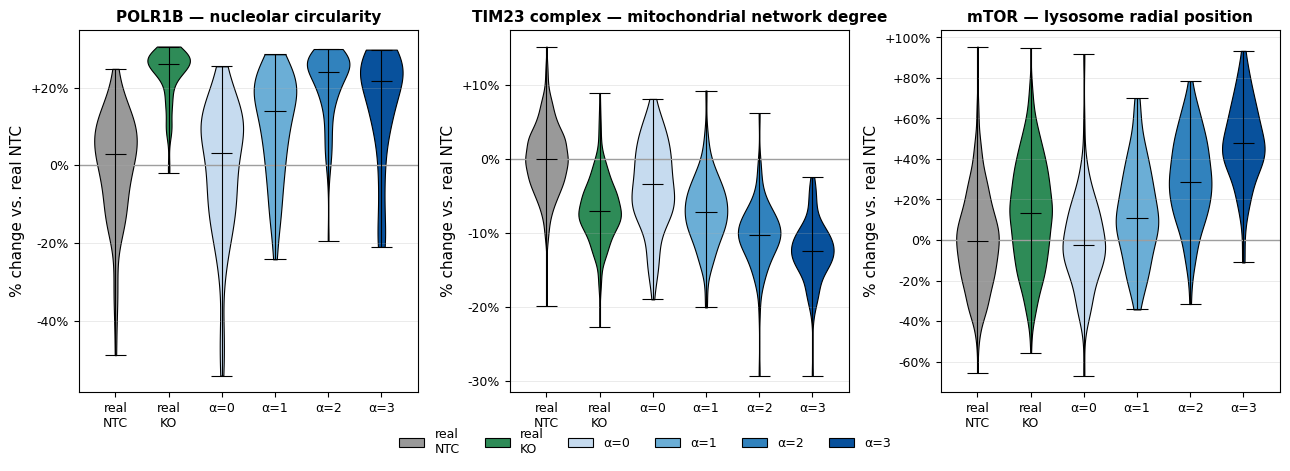

In [5]:
def pct(vals: np.ndarray, base: float) -> np.ndarray:
    return (vals - base) / abs(base) * 100.0


def plot_panel(ax, feat_data: dict[str, np.ndarray], title: str):
    base = float(np.mean(feat_data["real_ntc"]))
    pct_data = [pct(feat_data[s], base) for s in SERIES]

    vp = ax.violinplot(pct_data, positions=range(len(SERIES)), widths=0.8,
                       showmedians=True, showextrema=True)
    for body, s in zip(vp["bodies"], SERIES):
        body.set_facecolor(COLORS[s]); body.set_edgecolor("black")
        body.set_linewidth(0.8); body.set_alpha(1.0)
    for partname in ("cbars", "cmins", "cmaxes", "cmedians"):
        vp[partname].set_color("black"); vp[partname].set_linewidth(0.8)

    ax.axhline(0, color="#999", linewidth=1.0, zorder=1)
    ax.set_xticks(range(len(SERIES))); ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_ylabel("% change vs. real NTC", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.0f}%" if abs(v) >= 0.5 else "0%"))
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="y", linewidth=0.5, alpha=0.35)


fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, f in zip(axes, FEATURES):
    plot_panel(ax, data[f["key"]], f["title"])

handles = [mpatches.Patch(facecolor=COLORS[s], edgecolor="black", linewidth=0.8, label=lab)
          for s, lab in zip(SERIES, LABELS)]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.05), frameon=False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "counterfactual_traversal_violins.svg", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "counterfactual_traversal_violins.png", dpi=240, bbox_inches="tight")
plt.show()

## Summary table

Mean, median, and n per series per feature — the %-change values plotted above.

In [6]:
rows = []
for f in FEATURES:
    feat_data = data[f["key"]]
    base = float(np.mean(feat_data["real_ntc"]))
    for s in SERIES:
        vals = pct(feat_data[s], base)
        rows.append({
            "feature": f["key"], "series": s, "n": len(vals),
            "pct_mean": float(np.mean(vals)) if len(vals) else np.nan,
            "pct_median": float(np.median(vals)) if len(vals) else np.nan,
        })

summary = pd.DataFrame(rows)
summary.to_csv(FIGURES_DIR / "counterfactual_traversal_violins_summary.csv", index=False)
summary

,feature,series,n,pct_mean,pct_median
0,polr1b,real_ntc,98,-7.250436e-15,2.771675
1,polr1b,real_ko,93,2.355070e+01,26.039244
2,polr1b,gen_alpha0,96,-9.588165e-01,3.272324
3,polr1b,gen_alpha1,93,1.035971e+01,13.917968
4,polr1b,gen_alpha2,97,2.089349e+01,24.092334
5,polr1b,gen_alpha3,75,1.512397e+01,21.656208
6,tim23,real_ntc,1000,-1.302425e-14,-0.059391
7,tim23,real_ko,500,-6.770415e+00,-7.018413
8,tim23,gen_alpha0,100,-3.674906e+00,-3.483826
9,tim23,gen_alpha1,100,-7.045011e+00,-7.266370
